In [1]:
import numpy as np 
import pandas as pd 

In [2]:
games_df = pd.read_csv('/Users/ujjwalraj/Desktop/Project Import Material 1/games.csv')
sales_df = pd.read_csv('/Users/ujjwalraj/Desktop/Project Import Material 1/vgsales.csv')

In [3]:
games_df.head(4)

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K


In [4]:
games_df.shape

(1512, 14)

In [5]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB


In [6]:
games_df['Release Date'] = pd.to_datetime(games_df['Release Date'], format = '%b %d, %Y', errors = 'coerce')

In [7]:
def convert_k(value):
    if isinstance(value, str):
        value = value.strip().upper()
        if value.endswith('K'):
            return float(value.replace('K', '')) *1000
        if value.endswith('M'):
            return float(value.replace('M', '')) * 1000000
    return value

games_df['Times Listed'] = games_df['Times Listed'].apply(convert_k) 
games_df['Number of Reviews'] = games_df['Number of Reviews'].apply(convert_k) 
games_df['Plays'] = games_df['Plays'].apply(convert_k) 
games_df['Playing'] = games_df['Playing'].apply(convert_k) 
games_df['Backlogs'] = games_df['Backlogs'].apply(convert_k) 
games_df['Wishlist'] = games_df['Wishlist'].apply(convert_k) 

In [8]:
games_df['Times Listed'] = games_df['Times Listed'].astype(float)
games_df['Number of Reviews'] = games_df['Number of Reviews'].astype(float)
games_df['Plays'] = games_df['Plays'].astype(float) 
games_df['Playing'] = games_df['Playing'].astype(float)
games_df['Backlogs'] = games_df['Backlogs'].astype(float)
games_df['Wishlist'] = games_df['Wishlist'].astype(float)

In [9]:
games_df['Rating'].fillna(games_df['Rating']. median(), inplace = True)
games_df['Release Date'] = games_df['Release Date'].fillna(pd.Timestamp('2000-01-01')) 
games_df['Team'] = games_df['Team'].fillna(' ')
games_df['Summary'] = games_df['Summary'].fillna(' ')

In [10]:
games_df.isnull().sum()

Unnamed: 0           0
Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

In [11]:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         1512 non-null   int64         
 1   Title              1512 non-null   object        
 2   Release Date       1512 non-null   datetime64[ns]
 3   Team               1512 non-null   object        
 4   Rating             1512 non-null   float64       
 5   Times Listed       1512 non-null   float64       
 6   Number of Reviews  1512 non-null   float64       
 7   Genres             1512 non-null   object        
 8   Summary            1512 non-null   object        
 9   Reviews            1512 non-null   object        
 10  Plays              1512 non-null   float64       
 11  Playing            1512 non-null   float64       
 12  Backlogs           1512 non-null   float64       
 13  Wishlist           1512 non-null   float64       
dtypes: datet

In [12]:
# Cleaning Sales Dataset 
sales_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [13]:
sales_df.shape

(16598, 11)

In [14]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [15]:
sales_df['Year'] = pd.to_datetime(sales_df['Year'], format = '%Y')

In [16]:
sales_df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [17]:
sales_df['Year'] = sales_df['Year'].fillna(pd.Timestamp('2000'))
sales_df['Publisher'] = sales_df['Publisher'].fillna(' ')

In [18]:
# Clenaing the 'Title' of Both Dataset

def Clean_Title(title):
    if pd.isnull(title):
        return ''
    return str(title).lower().replace(':', '')

In [19]:
# Applying the Function We Have Created 
games_df['Clean_Title'] = games_df['Title'].apply(Clean_Title)
sales_df['Clean_Name'] = sales_df['Name'].apply(Clean_Title)

In [20]:
game_sales_df = pd.merge(games_df, sales_df, how = 'left', left_on = 'Clean_Title', right_on = 'Clean_Name')

In [21]:
game_sales_df.drop(columns = ['Clean_Title', 'Clean_Name'], inplace = True)

In [22]:
game_sales_df.head(3)

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,...,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,0,Elden Ring,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,3900.0,3900.0,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Hades,2019-12-10,['Supergiant Games'],4.3,2900.0,2900.0,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,The Legend of Zelda: Breath of the Wild,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",4.4,4300.0,4300.0,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Exploratory Data Analysis

In [23]:
#What are the top-rated games by user reviews
import matplotlib.pyplot as plt
import seaborn as sns

Top_Rated = games_df.sort_values(by = 'Rating', ascending = False).head(10)


<Axes: xlabel='Rating', ylabel='Title'>

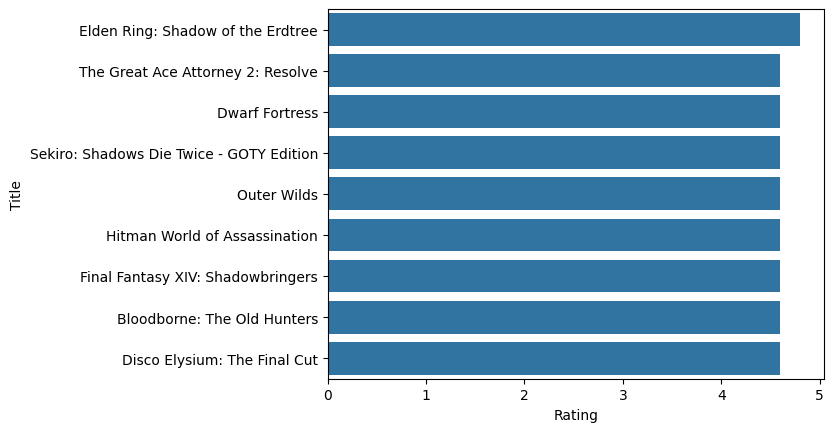

In [24]:
sns.barplot(x = 'Rating', y = 'Title', data = Top_Rated)

<Axes: ylabel='Team'>

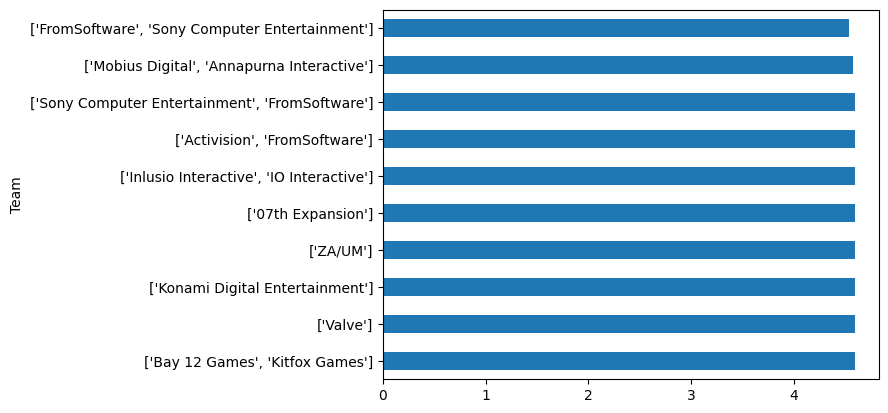

In [25]:
#Which developers (Teams) have the highest average ratings?
Average_Rating = games_df.groupby('Team')['Rating'].mean().sort_values(ascending = False).head(10)
Average_Rating.plot(kind = 'barh')

<Axes: >

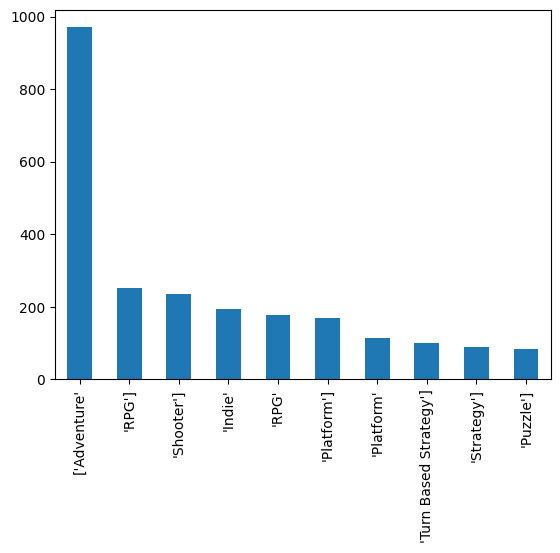

In [26]:
#What are the most common genres in the dataset?
from collections import Counter
common_genre = games_df['Genres'].str.split(', ').explode()
common_genre_count = common_genre.value_counts().head(10)
common_genre_count.plot(kind = 'bar')

<Axes: title={'center': 'Games with Highest Backlog Compared to Wishlist'}, xlabel='Title'>

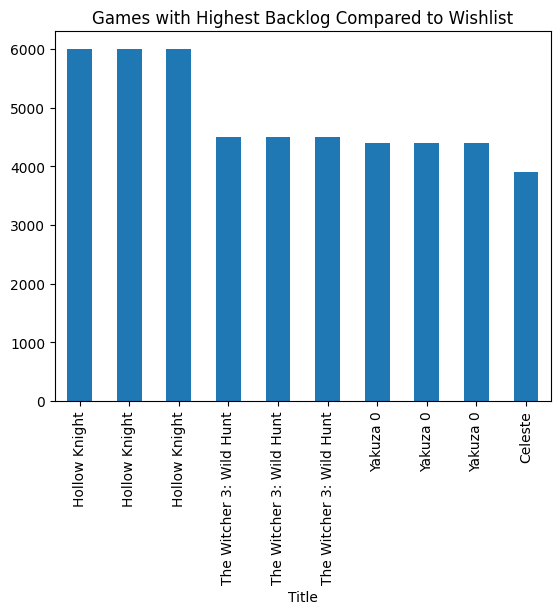

In [27]:
#Which games have the highest backlog compared to wishlist?
games_df['Backlog_gap'] = games_df['Backlogs'] - games_df['Wishlist'] 
Top_backlog_gap =(
    games_df[['Title', 'Backlogs', 'Wishlist', 'Backlog_gap']]
    .sort_values(by = 'Backlog_gap', ascending = False)
    .head(10)
)
Top_backlog_gap.set_index('Title')['Backlog_gap'].plot(
    kind = 'bar',
    title = 'Games with Highest Backlog Compared to Wishlist'
)

<Axes: >

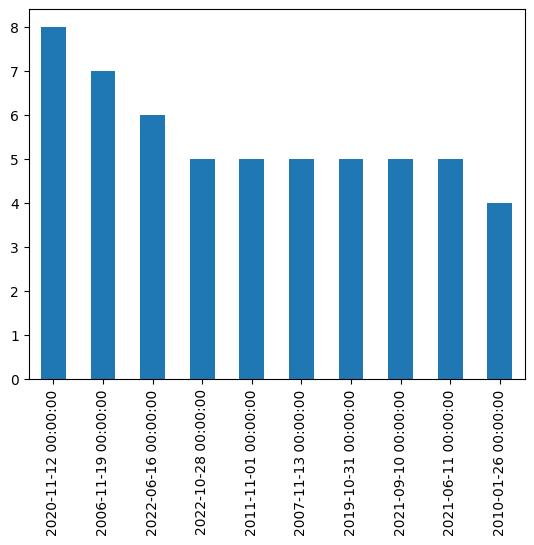

In [28]:
#What is the game release trend across years?
release_trend = games_df['Release Date'].value_counts().sort_values(ascending = False).head(10)
release_trend.plot(kind = 'bar')

<Axes: title={'center': 'Distribution of User Rating'}, ylabel='Frequency'>

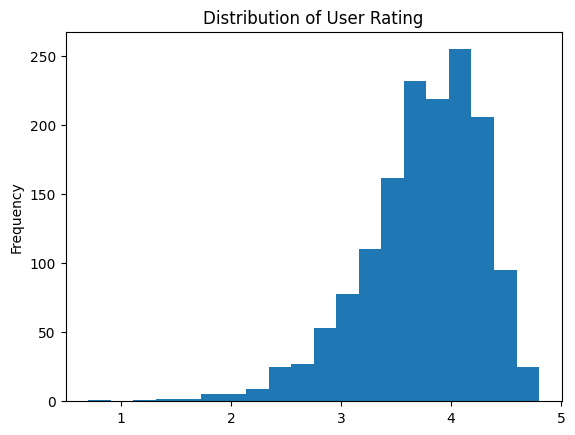

In [29]:
#What is the distribution of user ratings?
rating = games_df['Rating'].dropna()
rating.plot(
    kind = 'hist',
    bins = 20,
    title = 'Distribution of User Rating',
    xlabel = 'Rating',
    ylabel = 'Number of Games'
)

<Axes: xlabel='Wishlist', ylabel='Title'>

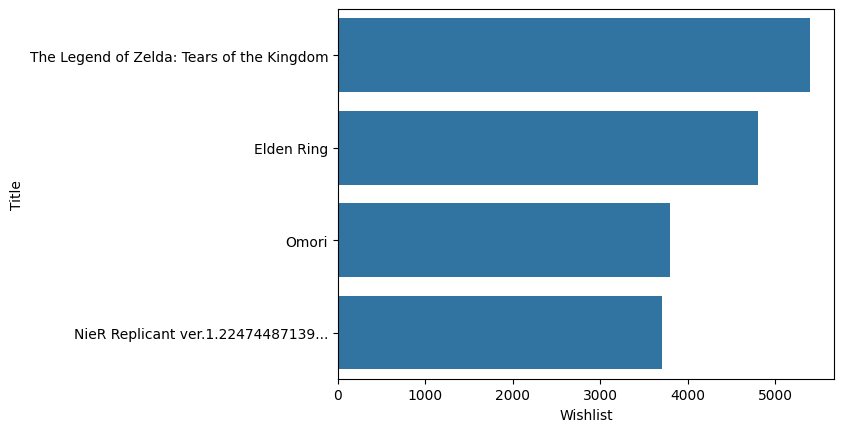

In [30]:
#What are the top 10 most wishlisted games?
Wishlisted_game = games_df[['Title', 'Wishlist']].sort_values(by = 'Wishlist', ascending = False).head(10)
sns.barplot(x = 'Wishlist' , y = 'Title' , data = Wishlisted_game)

In [31]:
#What’s the average number of plays per genre?
genre_df = games_df.copy()

genre_df['Genres'] = (
    genre_df['Genres']
    .astype(str)
    .str.replace('[', '', regex = False)
    .str.replace(']', '', regex = False)
    .str.replace("'", '', regex = False)
    .str.strip()
)

genre_df['Genres'] = genre_df['Genres'].str.split(', ')
genre_df = genre_df.explode('Genres')

genre_df['Plays'] = pd.to_numeric(genre_df['Plays'], errors = 'coerce')

avg_plays_per_genres = (
    genre_df
    .groupby('Genres')['Plays']
    .mean()
    .sort_values(ascending = False)
)
avg_plays_top = avg_plays_per_genres.head(10)

<Axes: xlabel='Genres'>

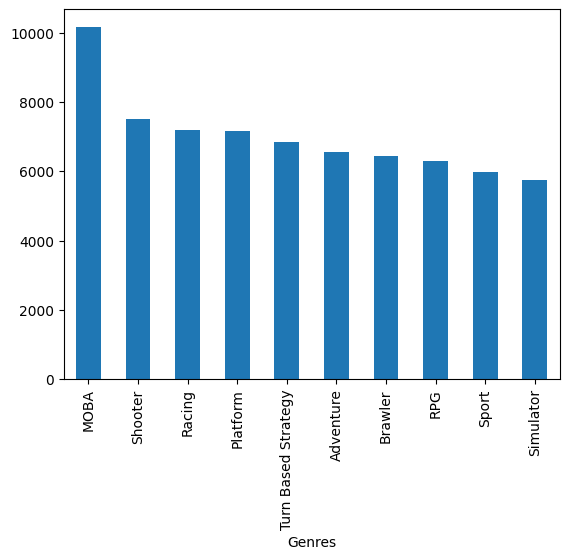

In [32]:
avg_plays_top.plot(kind = 'bar')

In [33]:
#Which developer studios are the most productive and impactful?
studio_state = (
    games_df
    .groupby('Team')
    .agg(
        total_game = ('Title', 'count'),
        Avg_rating = ('Rating', 'mean'),
        Avg_plays = ('Plays', 'mean')
     )
    .sort_values(by = 'total_game', ascending = False)
)

In [34]:
impactful_studio = studio_state[studio_state['total_game'] >= 5].sort_values(by = 'Avg_rating', ascending = False)

In [35]:
impactful_studio.head(10)

,total_game,Avg_rating,Avg_plays
Team,,,
['ZA/UM'],6,4.600000,5000.0
"['FromSoftware', 'Sony Computer Entertainment']",5,4.540000,11960.0
"['Konami Computer Entertainment Japan', 'Konami']",5,4.500000,8260.0
['Team Cherry'],5,4.440000,14160.0
"['Capcom', 'Capcom Development Division 1']",6,4.300000,13500.0
"['Sony Interactive Entertainment', 'SIE Santa Monica Studio']",6,4.300000,13150.0
"['Valve', 'Electronic Arts']",6,4.250000,28500.0
"['Ryū Ga Gotoku Studios', 'Sega']",6,4.233333,8267.0
"['Capcom', 'Capcom Production Studio 4']",5,4.220000,9640.0


<Axes: xlabel='Team'>

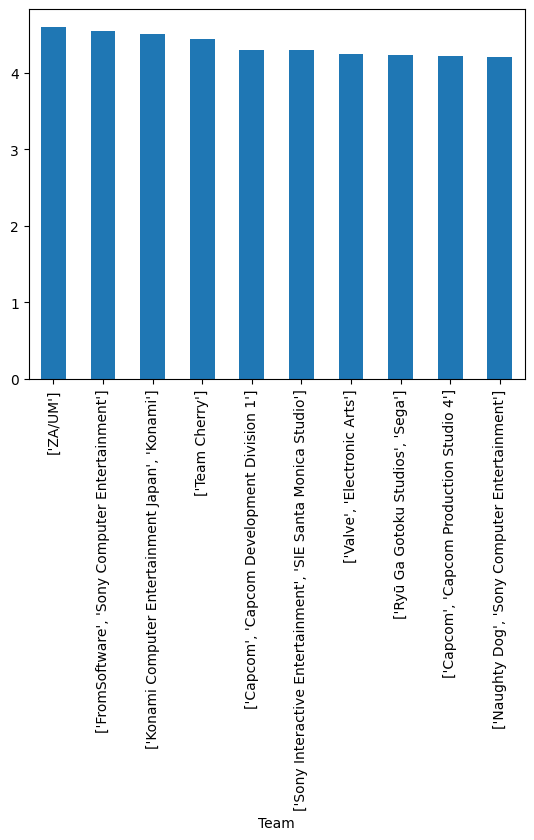

In [36]:
impactful_studio.head(10)['Avg_rating'].plot(kind = 'bar')

# vgsales Table

<Axes: >

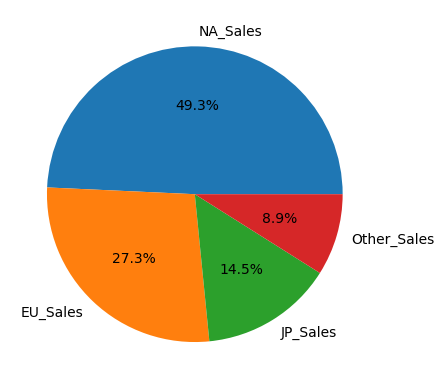

In [37]:
# Which region generates the most game sales?
region = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales']
Total_Sale = sales_df[region].sum()
Total_Sale.plot(kind = 'pie', autopct = '%1.1f%%')

<Axes: xlabel='Platform'>

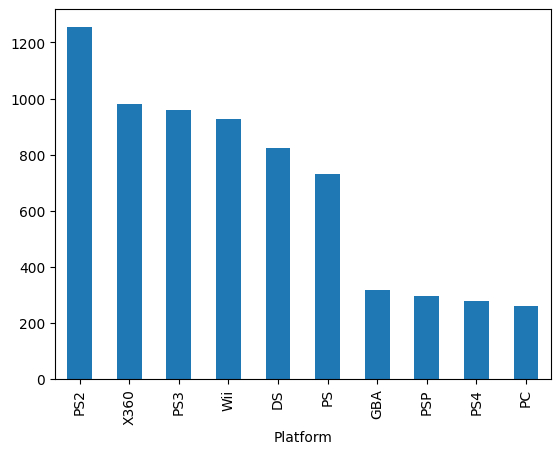

In [38]:
#What are the best-selling platforms?
Platform_sale = sales_df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending = False).head(10)
Platform_sale.plot(kind = 'bar')

<Axes: xlabel='Year'>

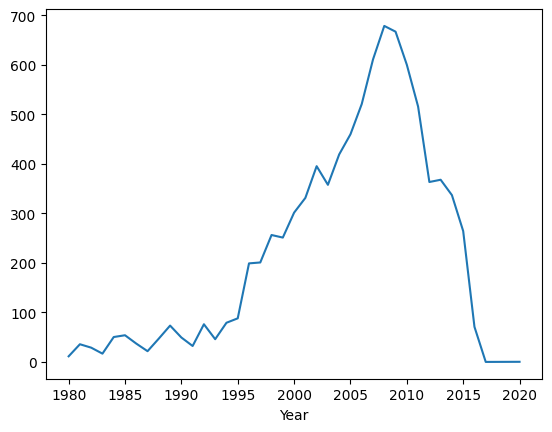

In [39]:
# What’s the trend of game releases and sales over years?
sale_visual = sales_df.copy()
sale_visual['Year'] = sale_visual['Year'].dt.year

trend = sale_visual.groupby('Year')['Global_Sales'].sum()
trend.plot(kind = 'line')

<Axes: ylabel='Publisher'>

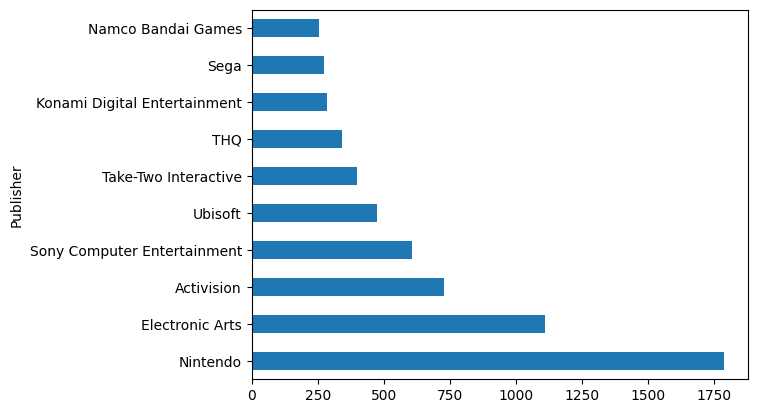

In [40]:
# Who are the top publishers by sales?
Top_Publisher = sale_visual.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending = False).head(10)
Top_Publisher.plot(kind = 'barh')

<Axes: xlabel='Global_Sales', ylabel='Name'>

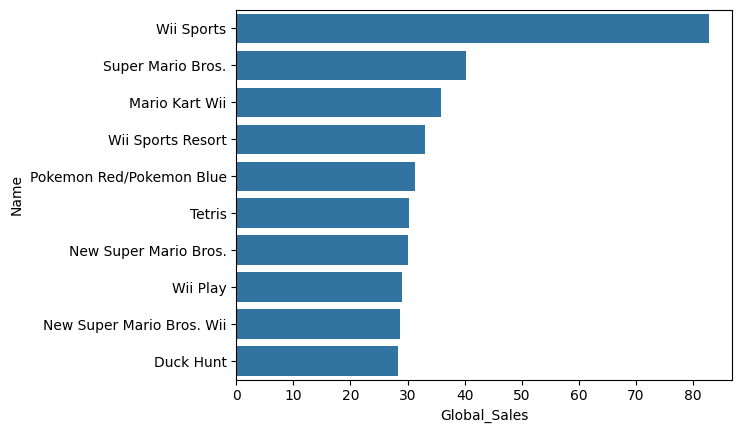

In [41]:
#Which games are the top 10 best-sellers globally?
Top_Game = sale_visual.sort_values(by = 'Global_Sales', ascending = False).head(10)
sns.barplot(x = 'Global_Sales', y = 'Name', data = Top_Game)

<Axes: >

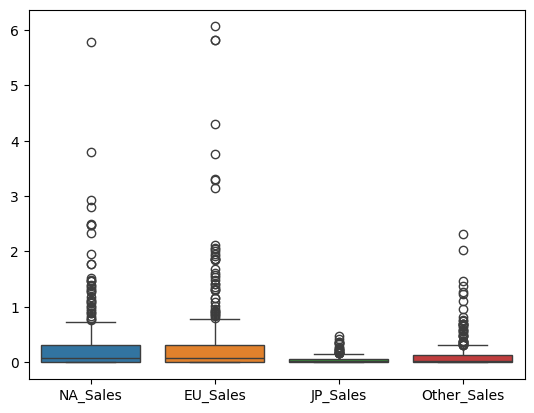

In [42]:
# How do regional sales compare for specific platforms?
Platofrm_compare = sale_visual[sale_visual['Platform'] == 'PS4']
sns.boxplot(data = Platofrm_compare[region])

<Axes: xlabel='Year'>

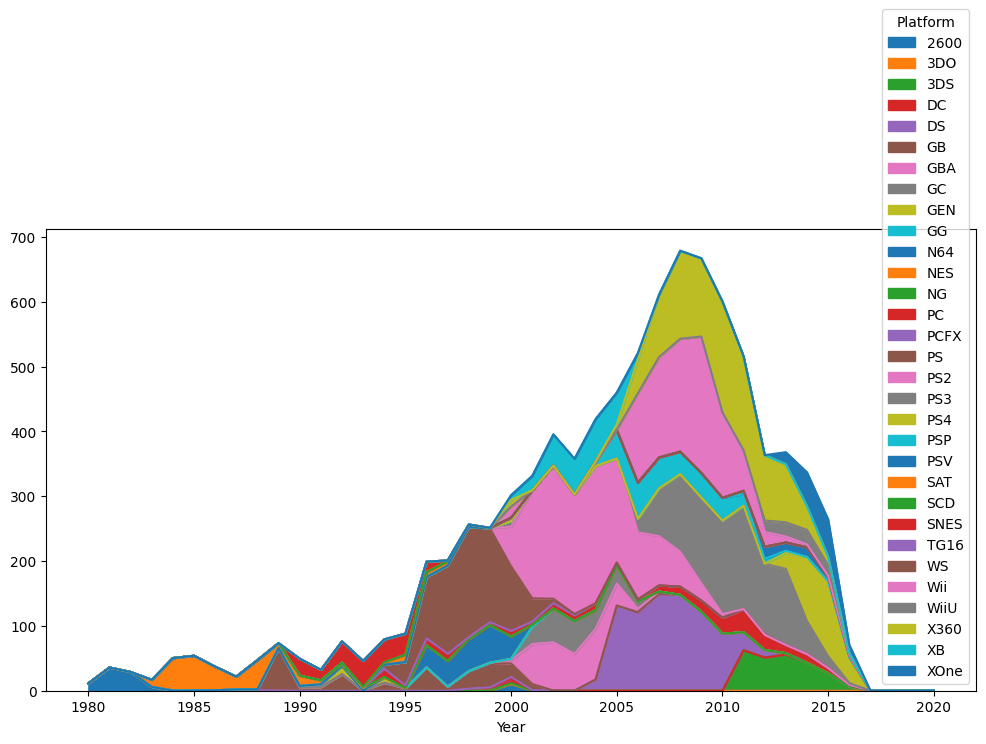

In [43]:
#How has the market evolved by platform over time?
Platform_sales = sale_visual.groupby(['Year', 'Platform'])['Global_Sales'].sum().unstack().fillna(0)
Platform_sales.plot.area(stacked = True, figsize = (12,6))


<Axes: xlabel='Genre'>

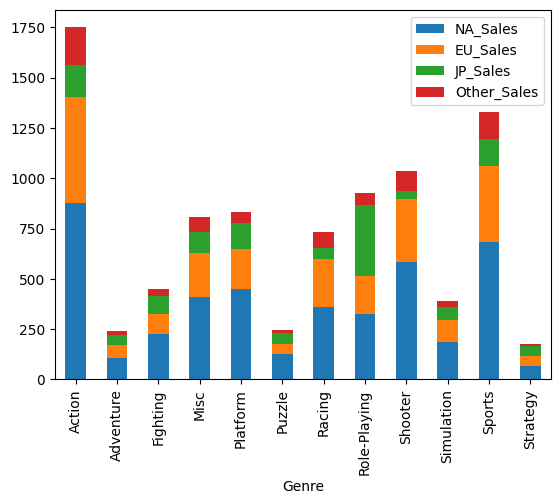

In [44]:
# What are the regional genre preferences?
Genre_Pre = sale_visual.groupby('Genre')[region].sum()
Genre_Pre.plot(kind = 'bar', stacked = True)

<Axes: xlabel='Year'>

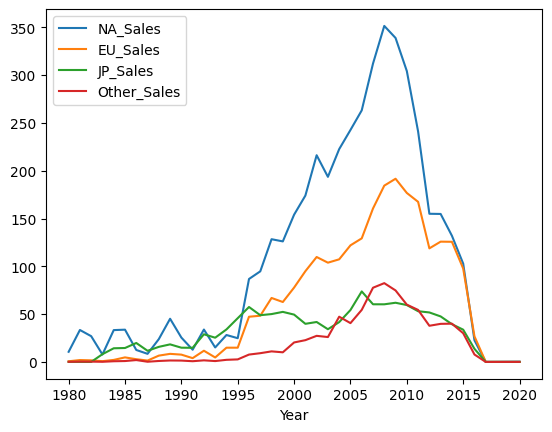

In [45]:
# What’s the yearly sales change per region?
Year_sales = sale_visual.groupby('Year')[region].sum()
Year_sales.plot(kind = 'line')

<Axes: ylabel='Publisher'>

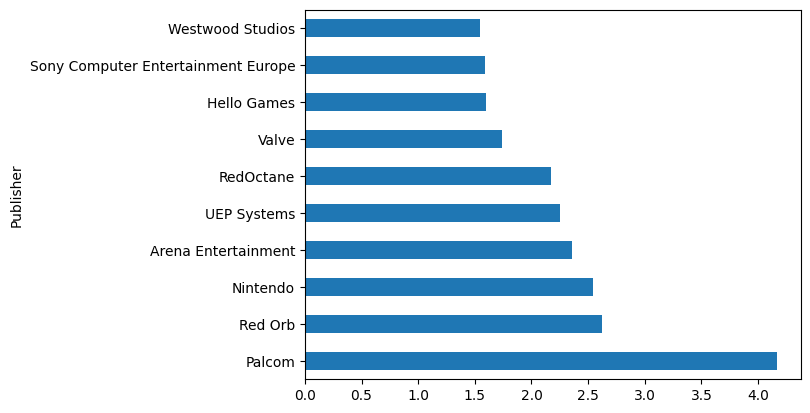

In [46]:
# What is the average sales per publisher?
Avg_Sales = sale_visual.groupby('Publisher')['Global_Sales'].mean().sort_values(ascending = False).head(10)
Avg_Sales.plot(kind = 'barh')

In [47]:
# What are the top 5 best-selling games per platform?
#sale_visual.groupby('')

In [48]:
sale_visual

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Clean_Name
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,wii sports
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,super mario bros.
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,mario kart wii
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,wii sports resort
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,pokemon red/pokemon blue
...,...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01,woody woodpecker in crazy castle 5
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01,men in black ii alien escape
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01,score international baja 1000 the official game
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01,know how 2


# Merge Datasets Table (Game + Sales)

In [49]:
game_sales_df.head(10)
game_sales_visual = game_sales_df.copy()

<Axes: ylabel='Genres'>

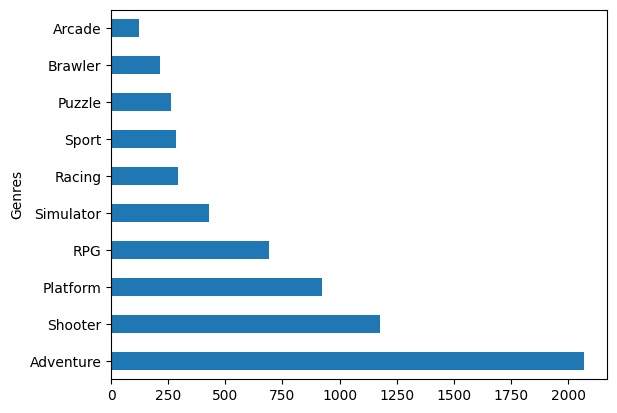

In [50]:
#Which game genres generate the most global sales?
game_sales_visual['Genres'] = (
    game_sales_visual['Genres']
    .astype(str)
    .str.replace('[', '', regex = False)
    .str.replace(']', '', regex = False)
    .str.replace("'", '', regex = False)
    .str.strip()
)
game_sales_visual['Genres'] = game_sales_visual['Genres'].str.split(', ')
game_sales_visual = game_sales_visual.explode('Genres')
game_sales_visual['Genre'] = game_sales_visual['Genres'].str.strip()

Gobal_sale = game_sales_visual.groupby('Genres')['Global_Sales'].sum().sort_values(ascending = False).head(10)
Gobal_sale.plot(kind = 'barh')

<Axes: title={'center': 'User Rating VS Global Sales'}, xlabel='User Rating', ylabel='Global_sales'>

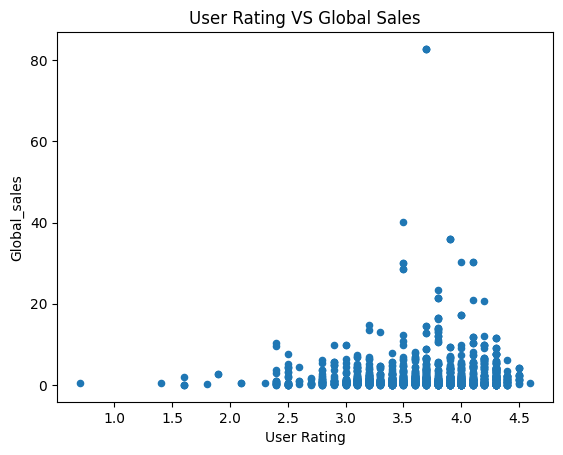

In [51]:
game_sale_visual1 = game_sales_df.copy()
# How does user rating affect global sales?
game_sale_visual1['Rating'] = pd.to_numeric(game_sale_visual1['Rating'], errors = 'coerce')
game_sale_visual1['Global_Sales'] = pd.to_numeric(game_sale_visual1['Global_Sales'], errors = 'coerce')

Global_Rating = game_sale_visual1[['Rating', 'Global_Sales']].dropna()

Correlation = Global_Rating['Rating'].corr(Global_Rating['Global_Sales'])
Global_Rating.plot(
    kind = 'scatter',
    x = 'Rating',
    y = 'Global_Sales',
    title = 'User Rating VS Global Sales',
    xlabel = 'User Rating',
    ylabel = 'Global_sales'
)

<Axes: xlabel='Platform'>

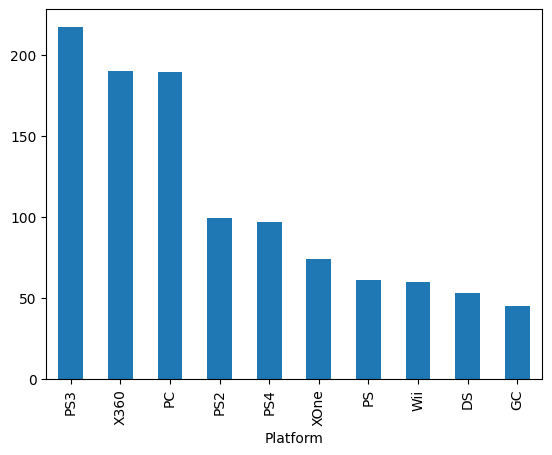

In [52]:
# Which platforms have the most games with high ratings (e.g., above 4)?
game_sale_visual1['Rating'] = pd.to_numeric(game_sale_visual1['Rating'], errors = 'coerce')

High_Rating = game_sale_visual1[game_sale_visual1['Rating'] > 4]

Platform_High_Rated = (
    game_sale_visual1
    .groupby('Platform')['Title']
    .count()
    .sort_values(ascending = False)
    .head(10)
) 
Platform_High_Rated.plot(kind = 'bar')

<Axes: xlabel='Release Date'>

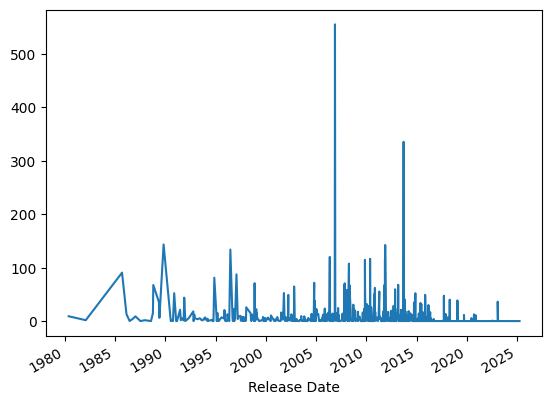

In [53]:
# What’s the trend of releases and sales over time?
Sales_treand = game_sales_visual.groupby('Release Date')['Global_Sales'].sum()
Sales_treand.plot(kind = 'line')

In [54]:
# Do highly wishlisted games lead to more sales?
#game_sales_visual['Wishlist'] = pd.to_numeric(game_sales_visual['Wishlist'], errors = 'coerce')
#game_sales_visual['Global_Sales'] = pd.to_numeric(game_sales_visual['Global_Sales'], errors = 'coerce')

#Wishlist_Sale_df = game_sales_visual[['Wishlist', 'Global_Sales']].dropna()
#Wishlist_Sale_df.plot(kind = 'scatter', x = 'Wishlist', y = 'Global_Sales')

In [55]:
# Which genres have the highest engagement but lowest sales?


In [56]:
#Highest_Engagement = game_sales_visual.groupby('Genres').agg(avg_play = ('Plays', 'mean'), avg_Sales = ('Global_Sales', 'mean'))
#Highest_Engagement.sort_values(by = 'avg_play', ascending = False)

In [57]:
# Do highly listed games (wishlist/backlogs) correlate with better ratings?
game_sales_visual['Wishlist'] = pd.to_numeric(game_sales_visual['Wishlist'], errors = 'coerce')
game_sales_visual['Backlogs'] = pd.to_numeric(game_sales_visual['Backlogs'], errors = 'coerce')
game_sales_visual['Rating'] = pd.to_numeric(game_sales_visual['Rating'], errors = 'coerce')

Rating_df = game_sales_visual[['Wishlist', 'Backlogs', 'Rating']]

Wishlist_corr = game_sales_visual['Wishlist'].corr(game_sales_visual['Rating'])
Backlog_corr = game_sales_visual['Backlogs'].corr(game_sales_visual['Rating'])


<Axes: title={'center': 'Wishlist And Rating'}, xlabel='Rating', ylabel='Wishlist'>

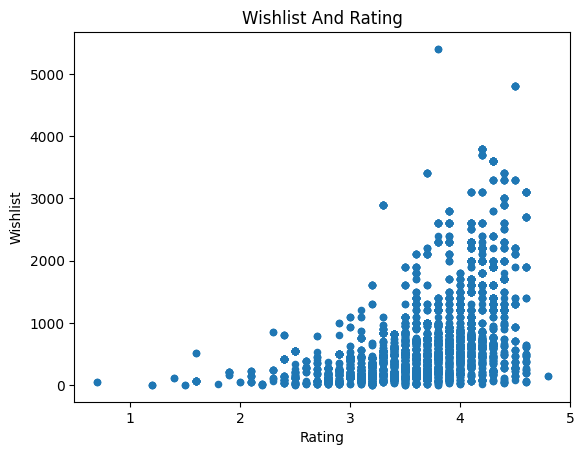

In [58]:
Rating_df.plot(
    kind = 'scatter',
    x = 'Rating',
    y = 'Wishlist',
    xlabel = 'Rating',
    ylabel = 'Wishlist',
    title = 'Wishlist And Rating'
)

<Axes: title={'center': 'Backlogs And Rating'}, xlabel='Rating', ylabel='backlogs'>

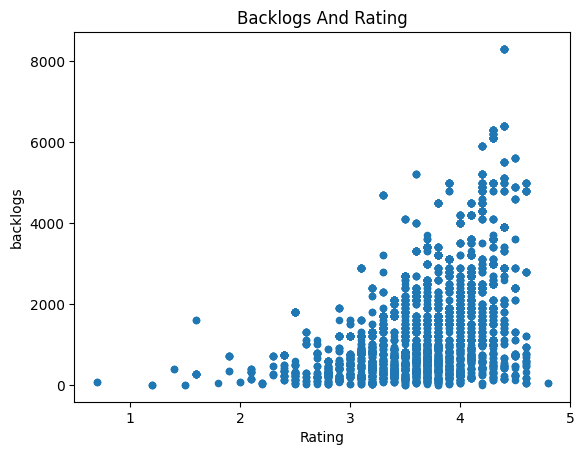

In [59]:
Rating_df.plot(
    kind = 'scatter',
    x = 'Rating',
    y = 'Backlogs',
    xlabel = 'Rating',
    ylabel = 'backlogs',
    title = 'Backlogs And Rating'
)

<Axes: ylabel='Genres'>

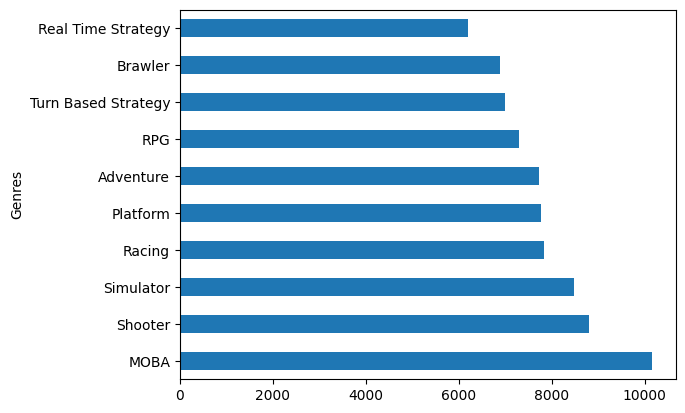

In [60]:
# How does user engagement differ across genres?
Highest_Engagement = game_sales_visual.groupby('Genres')['Plays'].mean().sort_values(ascending = False).head(10)
Highest_Engagement.plot(kind = 'barh')

In [61]:
# What are the top-performing combinations of Genre + Platform?
#game_sales_visual['Global_Sales'] = pd.to_numeric(game_sales_visual['Global_Sales'], errors = 'coerce')

#Genres_Platform_df = game_sales_visual[['Genres', 'Platform', 'Global_Sales']].dropna()
#Genres_Platform_df

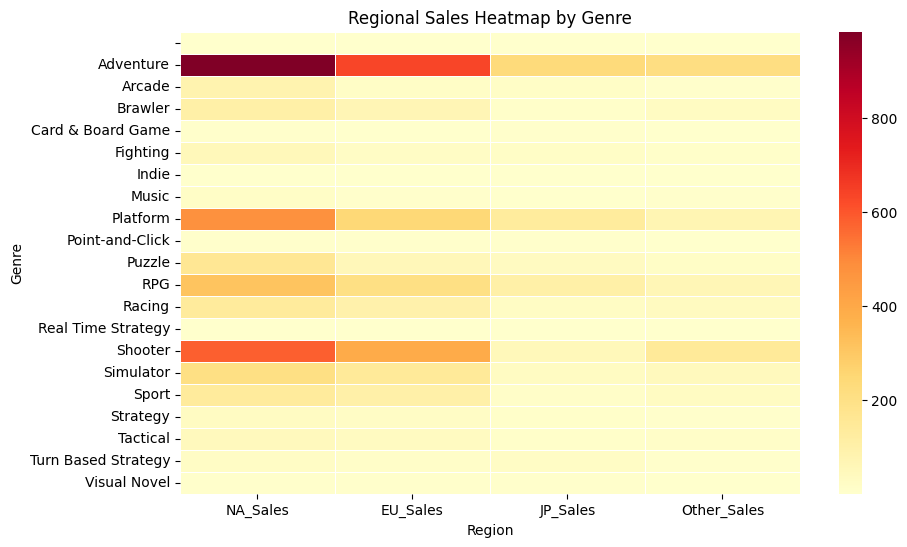

In [62]:
# What does a regional sales heatmap by genre reveal?
Regional_df = game_sales_visual[['Genres','NA_Sales','EU_Sales','JP_Sales','Other_Sales']].dropna()
Genre_Regional_Sales = (
    Regional_df
    .groupby('Genres')
    .agg(
        NA_Sales = ('NA_Sales', 'sum'),
        EU_Sales = ('EU_Sales', 'sum'),
        JP_Sales = ('JP_Sales', 'sum'),
        Other_Sales = ('Other_Sales', 'sum'),
    )
)
plt.figure(figsize = (10, 6))
sns.heatmap(Genre_Regional_Sales, cmap = 'YlOrRd', linewidths = 0.5)
plt.title('Regional Sales Heatmap by Genre')
plt.xlabel('Region')
plt.ylabel('Genre')
plt.show()

# Cleaning DataFrame Before Inserting in SQL DataBase

In [63]:
games_df.head(5)

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Clean_Title,Backlog_gap
0,0,Elden Ring,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,3900.0,3900.0,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17000.0,3800.0,4600.0,4800.0,elden ring,-200.0
1,1,Hades,2019-12-10,['Supergiant Games'],4.3,2900.0,2900.0,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21000.0,3200.0,6300.0,3600.0,hades,2700.0
2,2,The Legend of Zelda: Breath of the Wild,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",4.4,4300.0,4300.0,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30000.0,2500.0,5000.0,2600.0,the legend of zelda breath of the wild,2400.0
3,3,Undertale,2015-09-15,"['tobyfox', '8-4']",4.2,3500.0,3500.0,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28000.0,679.0,4900.0,1800.0,undertale,3100.0
4,4,Hollow Knight,2017-02-24,['Team Cherry'],4.4,3000.0,3000.0,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21000.0,2400.0,8300.0,2300.0,hollow knight,6000.0


In [64]:
# Dropping Unnamed Column 
games_df.drop(columns = 'Unnamed: 0', inplace = True)
games_df.drop(columns = 'Clean_Title', inplace = True)
games_df.drop(columns = 'Backlog_gap', inplace = True)
games_df.drop(columns = 'Reviews', inplace = True)
games_df.drop(columns = 'Summary', inplace = True)


In [65]:
games_df['Genres'] = (
    games_df['Genres']
    .astype(str)
    .str.replace('[', '', regex = False)
    .str.replace(']', '', regex = False)
    .str.replace("'", '', regex = False)
    .str.strip()
)

In [66]:
# Changing column name 
games_df = games_df.rename(columns = {
    'Release Date' : 'Release_Date',
    'Times Listed' : 'Times_Listed',
    'Number of Reviews' : 'Number_of_Reviews'
})

In [67]:
# Importing MySQL Connector
import mysql.connector

mydatabase = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Ujjwal@0608",
    database="VideoGame",   
    use_pure=True
)

print("Connection successful!")

Connection successful!


In [68]:
cursor = mydatabase.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS Games_Data(
    Title VARCHAR(100),
    Realease_Date DATETIME,
    Team VARCHAR(100),
    Rating FLOAT,
    Times_Listed FLOAT,
    Number_of_Reviews FLOAT,
    Genres VARCHAR(100),
    Plays FLOAT,
    Playing FLOAT,
    Backlogs FLOAT,
    Wishlist Float
)
''')

In [69]:
for _,rows in games_df.iterrows():
    
    try:
        cursor.execute('''
        INSERT INTO Games_Data
        (Title, Realease_Date, Team, Rating, Times_Listed, Number_of_Reviews, Genres, Plays, Playing, Backlogs, Wishlist)
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        ''',(
        rows['Title'],
        rows['Release_Date'],
        rows['Team'],
        rows['Rating'],
        rows['Times_Listed'],
        rows['Number_of_Reviews'],
        rows['Genres'],
        rows['Plays'],
        rows['Playing'],
        rows['Backlogs'],
        rows['Wishlist']
        ))
        mydatabase.commit()
    except mysql.connector.IntegrityError:
        print("Customers Table inserted!")


In [70]:
sales_df.drop(columns = 'Clean_Name', inplace = True)

In [71]:
sales_df = sales_df.rename(columns = {'Rank' : 'Rank_ID', 'Name' : 'name'})

In [72]:
sales_df

,Rank_ID,name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006-01-01,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985-01-01,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008-01-01,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009-01-01,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002-01-01,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003-01-01,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008-01-01,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010-01-01,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [73]:
cursor = mydatabase.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS Sales_Data(
    Rank_ID INT PRIMARY KEY,
    name VARCHAR(100),
    Platform VARCHAR(20),
    Year DATE,
    Genre VARCHAR(20),
    Publisher VARCHAR(50),
    NA_Sales FLOAT,
    EU_Sales FLOAT,
    JP_Sales FLOAT,
    Other_Sales FLOAT,
    Global_Sales Float
)
''')

In [74]:
for _,rows in sales_df.iterrows():
    
    try:
        cursor.execute('''
        INSERT INTO Sales_Data
        (Rank_ID, name, Platform, Year, Genre, Publisher, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales)
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        ''',(
        rows['Rank_ID'],
        rows['name'],
        rows['Platform'],
        rows['Year'],
        rows['Genre'],
        rows['Publisher'],
        rows['NA_Sales'],
        rows['EU_Sales'],
        rows['JP_Sales'],
        rows['Other_Sales'],
        rows['Global_Sales']
        ))
        mydatabase.commit()
    except mysql.connector.IntegrityError:
        print("Customers Table inserted!")


Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Table inserted!
Customers Ta

DataError: 1406 (22001): Data too long for column 'name' at row 1

In [75]:
Genres_DF = games_df[['Title', 'Genres']].copy()

Genres_DF['Genres'] = Genres_DF['Genres'].str.split(', ')
Genres_DF = Genres_DF.explode('Genres')

Genres_DF['Genres'] = Genres_DF['Genres'].str.strip()


In [76]:
Genres_DF

,Title,Genres
0,Elden Ring,Adventure
0,Elden Ring,RPG
1,Hades,Adventure
1,Hades,Brawler
1,Hades,Indie
...,...,...
1510,Baldur's Gate 3,Strategy
1510,Baldur's Gate 3,Tactical
1510,Baldur's Gate 3,Turn Based Strategy
1511,The LEGO Movie Videogame,Adventure


In [77]:
cursor = mydatabase.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS Genre_Data(
    Title VARCHAR(100),
    Genres VARCHAR(100)
)
''')

In [78]:
for _,rows in Genres_DF.iterrows():
    
    try:
        cursor.execute('''
        INSERT INTO Genre_Data
        (Title, Genres)
        VALUES (%s, %s)
        ''',(
        rows['Title'],
        rows['Genres']
        ))
        mydatabase.commit()
    except mysql.connector.IntegrityError:
        print("Customers Table inserted!")


# StreamLit Code 

In [79]:
%%writefile app.py
"""
Video Game Sales & Ratings Dashboard
-------------------------------------
Reproduces the cleaning + EDA from Video_Game_Sales_Analysis.ipynb as an
interactive Streamlit app. Reads directly from the two source CSVs
(no database dependency), so it can run locally or be deployed as-is.

Expected files (place inside a `data/` folder next to this script):
    data/games.csv    -> the review-site dataset (Title, Rating, Genres, Plays, ...)
    data/vgsales.csv  -> the classic sales dataset (Name, Platform, Year, Global_Sales, ...)
"""

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px

# --------------------------------------------------------------------------
# Page config
# --------------------------------------------------------------------------
st.set_page_config(
    page_title="Video Game Sales & Ratings Dashboard",
    page_icon="🎮",
    layout="wide",
)

DATA_DIR = "data"
REGIONS = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

# --------------------------------------------------------------------------
# Data loading + cleaning (mirrors the notebook, cached so it only runs once)
# --------------------------------------------------------------------------


def convert_k(value):
    """Turn strings like '3.2K' / '1.1M' into numbers."""
    if isinstance(value, str):
        value = value.strip().upper()
        if value.endswith("K"):
            return float(value.replace("K", "")) * 1_000
        if value.endswith("M"):
            return float(value.replace("M", "")) * 1_000_000
    return value


def clean_title(title):
    if pd.isnull(title):
        return ""
    return str(title).lower().replace(":", "")


@st.cache_data(show_spinner="Loading and cleaning data...")
def load_data():
    games_df = pd.read_csv("/Users/ujjwalraj/Desktop/Project Import Material 1/games.csv")
    sales_df = pd.read_csv("/Users/ujjwalraj/Desktop/Project Import Material 1/vgsales.csv")

    # ---- clean games_df ----
    games_df["Release Date"] = pd.to_datetime(
        games_df["Release Date"], format="%b %d, %Y", errors="coerce"
    )
    for col in ["Times Listed", "Number of Reviews", "Plays", "Playing", "Backlogs", "Wishlist"]:
        games_df[col] = games_df[col].apply(convert_k).astype(float)

    games_df["Rating"] = games_df["Rating"].fillna(games_df["Rating"].median())
    games_df["Release Date"] = games_df["Release Date"].fillna(pd.Timestamp("2000-01-01"))
    games_df["Team"] = games_df["Team"].fillna(" ")
    games_df["Summary"] = games_df["Summary"].fillna(" ")

    games_df["Genres"] = (
        games_df["Genres"]
        .astype(str)
        .str.replace("[", "", regex=False)
        .str.replace("]", "", regex=False)
        .str.replace("'", "", regex=False)
        .str.strip()
    )

    games_df["Backlog_gap"] = games_df["Backlogs"] - games_df["Wishlist"]

    # ---- clean sales_df ----
    sales_df["Year"] = pd.to_datetime(sales_df["Year"], format="%Y", errors="coerce")
    sales_df["Year"] = sales_df["Year"].fillna(pd.Timestamp("2000"))
    sales_df["Publisher"] = sales_df["Publisher"].fillna(" ")

    # ---- merge ----
    games_df["Clean_Title"] = games_df["Title"].apply(clean_title)
    sales_df["Clean_Name"] = sales_df["Name"].apply(clean_title)
    merged_df = pd.merge(
        games_df, sales_df, how="left", left_on="Clean_Title", right_on="Clean_Name"
    )
    merged_df.drop(columns=["Clean_Title", "Clean_Name"], inplace=True)

    return games_df, sales_df, merged_df


@st.cache_data(show_spinner=False)
def explode_genres(df, genre_col="Genres"):
    exploded = df.copy()
    exploded[genre_col] = exploded[genre_col].astype(str).str.split(", ")
    exploded = exploded.explode(genre_col)
    exploded[genre_col] = exploded[genre_col].str.strip()
    return exploded


try:
    games_df, sales_df, merged_df = load_data()
except FileNotFoundError:
    st.error(
        "Couldn't find `data/games.csv` and/or `data/vgsales.csv`. "
        "Create a `data/` folder next to `app.py` and place both CSVs inside it."
    )
    st.stop()

# --------------------------------------------------------------------------
# Sidebar
# --------------------------------------------------------------------------
st.sidebar.title("🎮 Dashboard Filters")

section = st.sidebar.radio(
    "Section",
    ["Overview", "Game Ratings & Engagement (games.csv)", "Global Sales (vgsales.csv)", "Merged Insights"],
)

st.sidebar.markdown("---")
st.sidebar.caption(
    f"Games dataset: {len(games_df):,} titles\n\n"
    f"Sales dataset: {len(sales_df):,} platform-level records"
)

# --------------------------------------------------------------------------
# Overview
# --------------------------------------------------------------------------
if section == "Overview":
    st.title("🎮 Video Game Sales & Ratings Dashboard")
    st.markdown(
        "Exploring two datasets: user ratings/engagement (**games.csv**) and "
        "historical **global sales** (**vgsales.csv**), plus a merged view."
    )

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Titles (games.csv)", f"{len(games_df):,}")
    c2.metric("Sales records (vgsales.csv)", f"{len(sales_df):,}")
    c3.metric("Avg. rating", f"{games_df['Rating'].mean():.2f} / 5")
    c4.metric("Total global sales", f"{sales_df['Global_Sales'].sum():,.0f}M units")

    st.markdown("### Global sales trend over time")
    trend = sales_df.copy()
    trend["Year"] = trend["Year"].dt.year
    trend = trend[trend["Year"] > 1980].groupby("Year")["Global_Sales"].sum().reset_index()
    fig = px.area(trend, x="Year", y="Global_Sales", labels={"Global_Sales": "Global Sales (M units)"})
    st.plotly_chart(fig, use_container_width=True)

    st.info(
        "Use the sidebar to explore ratings & engagement, sales figures, "
        "or the merged dataset in depth."
    )

# --------------------------------------------------------------------------
# Games (ratings / engagement) section
# --------------------------------------------------------------------------
elif section == "Game Ratings & Engagement (games.csv)":
    st.title("Game Ratings & Engagement")

    top_n = st.sidebar.slider("Top N", 5, 20, 10)

    tab1, tab2, tab3, tab4 = st.tabs(
        ["Top Rated", "Genres & Studios", "Backlog / Wishlist", "Release & Rating Trends"]
    )

    with tab1:
        st.subheader("Top-rated games by user reviews")
        top_rated = games_df.sort_values("Rating", ascending=False).head(top_n)
        fig = px.bar(top_rated, x="Rating", y="Title", orientation="h", color="Rating")
        fig.update_layout(yaxis={"categoryorder": "total ascending"})
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Top wishlisted games")
        wishlisted = games_df[["Title", "Wishlist"]].sort_values("Wishlist", ascending=False).head(top_n)
        fig = px.bar(wishlisted, x="Wishlist", y="Title", orientation="h", color="Wishlist")
        fig.update_layout(yaxis={"categoryorder": "total ascending"})
        st.plotly_chart(fig, use_container_width=True)

    with tab2:
        st.subheader("Most common genres")
        genre_exp = explode_genres(games_df)
        genre_counts = genre_exp["Genres"].value_counts().head(top_n).reset_index()
        genre_counts.columns = ["Genre", "Count"]
        fig = px.bar(genre_counts, x="Genre", y="Count", color="Count")
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Average plays per genre")
        genre_exp["Plays"] = pd.to_numeric(genre_exp["Plays"], errors="coerce")
        avg_plays = genre_exp.groupby("Genres")["Plays"].mean().sort_values(ascending=False).head(top_n)
        fig = px.bar(avg_plays.reset_index(), x="Genres", y="Plays", color="Plays")
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Highest-rated studios (5+ games)")
        studio_stats = (
            games_df.groupby("Team")
            .agg(total_games=("Title", "count"), avg_rating=("Rating", "mean"), avg_plays=("Plays", "mean"))
            .sort_values("total_games", ascending=False)
        )
        impactful = studio_stats[studio_stats["total_games"] >= 5].sort_values("avg_rating", ascending=False).head(top_n)
        fig = px.bar(impactful.reset_index(), x="Team", y="avg_rating", color="avg_rating")
        st.plotly_chart(fig, use_container_width=True)

    with tab3:
        st.subheader("Games with the highest backlog-vs-wishlist gap")
        top_gap = (
            games_df[["Title", "Backlogs", "Wishlist", "Backlog_gap"]]
            .sort_values("Backlog_gap", ascending=False)
            .head(top_n)
        )
        fig = px.bar(top_gap, x="Title", y="Backlog_gap", color="Backlog_gap")
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Rating vs. Wishlist / Backlogs")
        c1, c2 = st.columns(2)
        with c1:
            fig = px.scatter(games_df, x="Rating", y="Wishlist", opacity=0.5, trendline="ols")
            st.plotly_chart(fig, use_container_width=True)
        with c2:
            fig = px.scatter(games_df, x="Rating", y="Backlogs", opacity=0.5, trendline="ols")
            st.plotly_chart(fig, use_container_width=True)

    with tab4:
        st.subheader("Distribution of user ratings")
        fig = px.histogram(games_df, x="Rating", nbins=20)
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Release volume over time (by year)")
        release_by_year = games_df.copy()
        release_by_year["Year"] = release_by_year["Release Date"].dt.year
        release_by_year = release_by_year[release_by_year["Year"] > 1980]
        counts = release_by_year["Year"].value_counts().sort_index().reset_index()
        counts.columns = ["Year", "Releases"]
        fig = px.line(counts, x="Year", y="Releases", markers=True)
        st.plotly_chart(fig, use_container_width=True)

# --------------------------------------------------------------------------
# Sales section
# --------------------------------------------------------------------------
elif section == "Global Sales (vgsales.csv)":
    st.title("Global Sales")

    top_n = st.sidebar.slider("Top N", 5, 20, 10)
    sale_visual = sales_df.copy()
    sale_visual["Year"] = sale_visual["Year"].dt.year

    tab1, tab2, tab3 = st.tabs(["By Region / Platform", "By Publisher / Game", "Over Time"])

    with tab1:
        c1, c2 = st.columns(2)
        with c1:
            st.subheader("Sales share by region")
            total_sale = sale_visual[REGIONS].sum().reset_index()
            total_sale.columns = ["Region", "Sales"]
            fig = px.pie(total_sale, names="Region", values="Sales", hole=0.4)
            st.plotly_chart(fig, use_container_width=True)
        with c2:
            st.subheader("Best-selling platforms")
            platform_sale = sale_visual.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(top_n)
            fig = px.bar(platform_sale.reset_index(), x="Platform", y="Global_Sales", color="Global_Sales")
            st.plotly_chart(fig, use_container_width=True)

        st.subheader("Regional sales comparison for a chosen platform")
        platform_choice = st.selectbox("Platform", sorted(sale_visual["Platform"].unique()), index=0)
        platform_data = sale_visual[sale_visual["Platform"] == platform_choice]
        fig = px.box(platform_data[REGIONS])
        st.plotly_chart(fig, use_container_width=True)

    with tab2:
        st.subheader("Top publishers by total sales")
        top_pub = sale_visual.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(top_n)
        fig = px.bar(top_pub.reset_index(), x="Global_Sales", y="Publisher", orientation="h", color="Global_Sales")
        fig.update_layout(yaxis={"categoryorder": "total ascending"})
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Top-selling games globally")
        top_games = sale_visual.sort_values("Global_Sales", ascending=False).head(top_n)
        fig = px.bar(top_games, x="Global_Sales", y="Name", orientation="h", color="Global_Sales")
        fig.update_layout(yaxis={"categoryorder": "total ascending"})
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Average sales per publisher")
        avg_sales = sale_visual.groupby("Publisher")["Global_Sales"].mean().sort_values(ascending=False).head(top_n)
        fig = px.bar(avg_sales.reset_index(), x="Publisher", y="Global_Sales", color="Global_Sales")
        st.plotly_chart(fig, use_container_width=True)

    with tab3:
        st.subheader("Global sales trend over years")
        yearly = sale_visual[sale_visual["Year"] > 1980].groupby("Year")["Global_Sales"].sum().reset_index()
        fig = px.line(yearly, x="Year", y="Global_Sales", markers=True)
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Market evolution by platform over time")
        platform_sales = (
            sale_visual[sale_visual["Year"] > 1980]
            .groupby(["Year", "Platform"])["Global_Sales"]
            .sum()
            .reset_index()
        )
        fig = px.area(platform_sales, x="Year", y="Global_Sales", color="Platform")
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Yearly sales by region")
        year_region = sale_visual[sale_visual["Year"] > 1980].groupby("Year")[REGIONS].sum().reset_index()
        fig = px.line(year_region, x="Year", y=REGIONS, markers=False)
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Regional genre preferences")
        genre_region = sale_visual.groupby("Genre")[REGIONS].sum()
        fig = px.bar(genre_region.reset_index(), x="Genre", y=REGIONS, barmode="stack")
        st.plotly_chart(fig, use_container_width=True)

# --------------------------------------------------------------------------
# Merged section
# --------------------------------------------------------------------------
else:
    st.title("Merged Insights (games.csv + vgsales.csv)")
    st.caption(
        "Note: this merge is on cleaned title text. Not every game in games.csv has "
        "an exact match in vgsales.csv, and matched titles can appear once per platform, "
        "so treat these charts as a partial-coverage view rather than the full catalog."
    )

    top_n = st.sidebar.slider("Top N", 5, 20, 10)
    merged = merged_df.copy()
    merged["Rating"] = pd.to_numeric(merged["Rating"], errors="coerce")
    merged["Global_Sales"] = pd.to_numeric(merged["Global_Sales"], errors="coerce")

    tab1, tab2 = st.tabs(["Genre Sales", "Rating vs Sales"])

    with tab1:
        st.subheader("Global sales by genre")
        genre_merged = explode_genres(merged)
        genre_sales = genre_merged.groupby("Genres")["Global_Sales"].sum().sort_values(ascending=False).head(top_n)
        fig = px.bar(genre_sales.reset_index(), x="Genres", y="Global_Sales", color="Global_Sales")
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Regional sales heatmap by genre")
        regional = genre_merged[["Genres"] + REGIONS].dropna()
        regional_agg = regional.groupby("Genres")[REGIONS].sum()
        fig = px.imshow(regional_agg, aspect="auto", color_continuous_scale="YlOrRd", labels=dict(color="Sales"))
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("User engagement (avg. plays) by genre")
        genre_merged["Plays"] = pd.to_numeric(genre_merged["Plays"], errors="coerce")
        engagement = genre_merged.groupby("Genres")["Plays"].mean().sort_values(ascending=False).head(top_n)
        fig = px.bar(engagement.reset_index(), x="Plays", y="Genres", orientation="h", color="Plays")
        fig.update_layout(yaxis={"categoryorder": "total ascending"})
        st.plotly_chart(fig, use_container_width=True)

    with tab2:
        rating_sales = merged[["Rating", "Global_Sales"]].dropna()
        corr = rating_sales["Rating"].corr(rating_sales["Global_Sales"])
        st.metric("Correlation: Rating vs Global Sales", f"{corr:.3f}")

        fig = px.scatter(rating_sales, x="Rating", y="Global_Sales", opacity=0.4, trendline="ols")
        st.plotly_chart(fig, use_container_width=True)

        st.subheader("Games with high ratings (> 4) by platform")
        high_rating = merged[merged["Rating"] > 4]
        platform_high = high_rating["Platform"].value_counts().head(top_n).reset_index()
        platform_high.columns = ["Platform", "Count"]
        fig = px.bar(platform_high, x="Platform", y="Count", color="Count")
        st.plotly_chart(fig, use_container_width=True)



Overwriting app.py


In [ ]:
!streamlit run app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://192.168.29.218:8502

2026-08-01 20:44:14.183 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:44:24.668 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:44:24.694 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:44:24.751 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.



2026-08-01 20:45:04.535 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:45:04.557 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:45:04.584 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:45:04.608 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:45:04.637 

2026-08-01 20:45:12.385 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:45:12.405 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:45:12.423 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:45:20.191 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-01 20:45:20.211 